# Employee Attrition Prediction 
# XYlofy AI Internship Week 2

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [20]:
df = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [21]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1470
Columns: 35


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [23]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [24]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [25]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [26]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [27]:
(
    df["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

In [28]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("Number of Numerical Columns:", len(numeric_cols))
print(numeric_cols.tolist())

Number of Numerical Columns: 26
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [29]:
categorical_cols = df.select_dtypes(include="object").columns

print("Number of Categorical Columns:", len(categorical_cols))
print(categorical_cols.tolist())

Number of Categorical Columns: 9
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_380\2281626446.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [30]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [31]:
df.describe(include="object")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_380\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


# Day 1 Observations

## Dataset Summary

- Dataset contains 1470 employee records.
- Dataset contains 35 columns.
- Target variable is Attrition.
- No missing values found.
- No duplicate records found.
- Dataset contains both numerical and categorical features.
- Attrition dataset is imbalanced.
- Several categorical variables will require encoding before model training.

## Next Step 

Day 2  will focus on:
- Data Cleaning 
- Feature Encoding
- Preparing data for Machine Learning.

# Day 2: Data Cleaning & Preprocessing

In [32]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [33]:
categorical_cols = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_cols.tolist())

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_380\1521185969.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [34]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


Attrition
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

BusinessTravel
<StringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str

Department
<StringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str

EducationField
<StringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str

Gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

JobRole
<StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str

MaritalStatus
<StringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str

Over18
<StringArray>
['Y']
Length: 1, dtype: str

OverTime
<StringArray>
['Yes', 'No']
Length: 2,

In [35]:
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

EmployeeCount
Over18
StandardHours


In [37]:
df.drop(
    columns=[
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ],
    inplace=True
)

In [38]:
print(df.shape)

(1470, 32)


In [39]:
df["Attritioh"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

df["Attrition"].value_counts

<bound method IndexOpsMixin.value_counts of 0       Yes
1        No
2       Yes
3        No
4        No
       ... 
1465     No
1466     No
1467     No
1468     No
1469     No
Name: Attrition, Length: 1470, dtype: str>

In [42]:
categorical_cols = df.select_dtypes(include="object").columns

label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("Encoding completed successfully.")

Encoding completed successfully.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_380\3792573490.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   int64
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   int64
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   int64
 8   EmployeeNumber            1470 non-null   int64
 9   EnvironmentSatisfaction   1470 non-null   int64
 10  Gender                    1470 non-null   int64
 11  HourlyRate                1470 non-null   int64
 12  JobInvolvement            1470 non-null   int64
 13  JobLevel                  1470 non-null   int64
 14  JobRole                   1470 non-null   int64
 15

In [44]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

print(X.shape)
print(y.shape)

(1470, 32)
(1470,)


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1176, 32)
X_test : (294, 32)
y_train: (1176,)
y_test : (294,)


In [50]:
df.to_csv("data/Employee_Attrition_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Day 2 Markdown

## Data Cleaning Summary

- Removed constant columns:
  - EmployeeCount
  - Over18
  - StandardHours

- Encoded target variable:
  - No -> 0
  - Yes -> 1

- Label encoded all categorical features.

- Created Features (X) and Target (y).

- Split Dataset info:
  - 80% Training Data 
  - 20% Testing Data

## Final Dataset 

- Rows: 1470
- Columns: 32

Dataset is now ready for Exploratory Data Analysis and Machine Learning.

# Day 3: Exploratory Data Analysis (EDA)

In [51]:
import os
os.makedirs("charts", exist_ok=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_380\1653132498.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


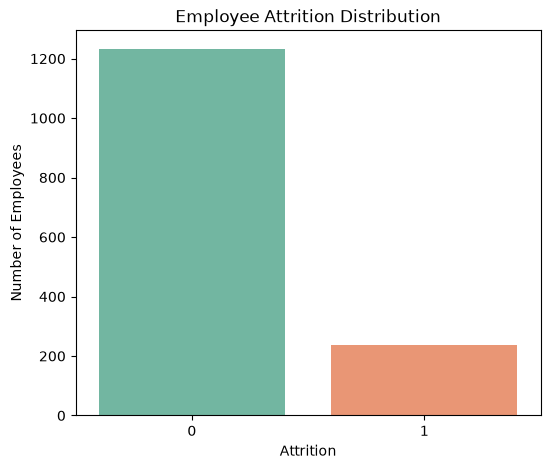

In [52]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="Attrition",
    data=df,
    palette="Set2"
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.savefig(
    "charts/attrition_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Observation

- Majority of employees did not leave the company.
- Attrtion dataset is imbalanced.
- Around 16% employees left.

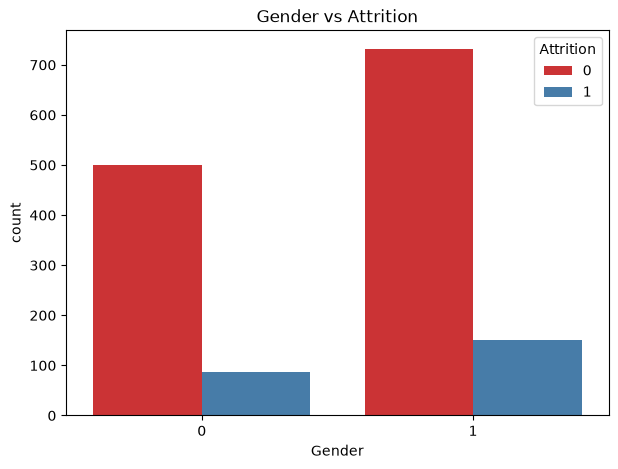

In [53]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Gender",
    hue="Attrition",
    data=df,
    palette="Set1"
)

plt.title("Gender vs Attrition")

plt.savefig(
    "charts/gender_attrition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Compare attrition between male and female employees.
- Observe whether one gender has noticeably higher attrition.

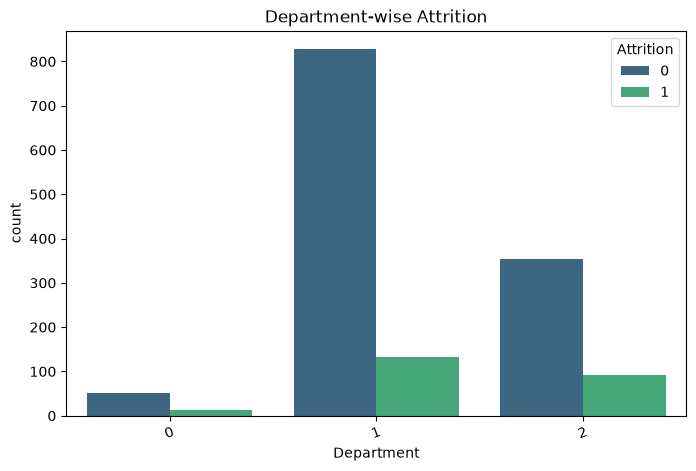

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Department",
    hue="Attrition",
    data=df,
    palette="viridis"
)

plt.xticks(rotation=20)

plt.title("Department-wise Attrition")

plt.savefig(
    "charts/department_attrition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Research & Development has the highest number of employees.
- Compare which department experiences higher employee turnover.

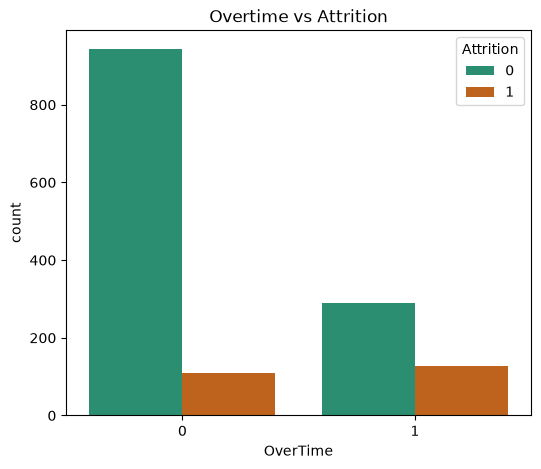

In [55]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="OverTime",
    hue="Attrition",
    data=df,
    palette="Dark2"
)

plt.title("Overtime vs Attrition")

plt.savefig(
    "charts/overtime_attrition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Employees working overtime appear more likely to leave.
- Overtime may be a major factor influencing attrition.

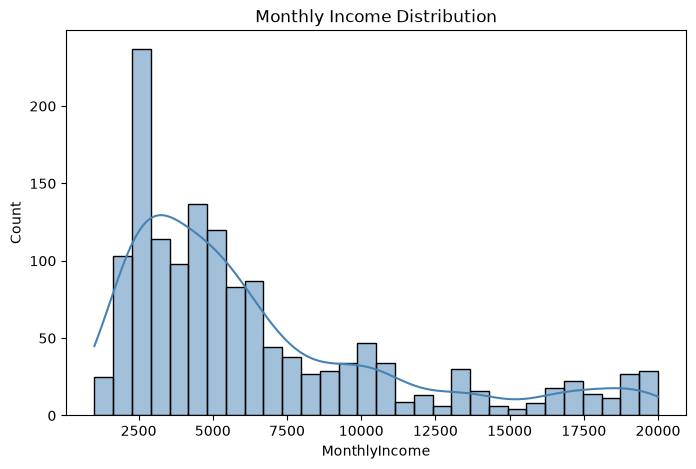

In [56]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyIncome"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Monthly Income Distribution")

plt.savefig(
    "charts/monthly_income_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Income is right-skewed.
- Most employees fall into the lower income range.

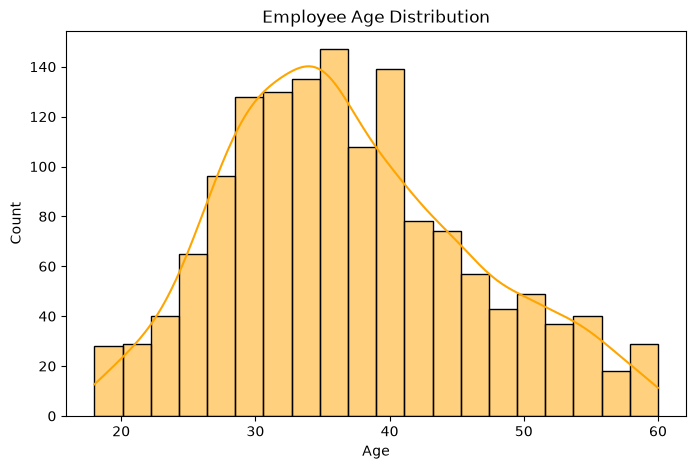

In [57]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=20,
    kde=True,
    color="orange"
)

plt.title("Employee Age Distribution")

plt.savefig(
    "charts/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

- Most employees are between 30–40 years old.

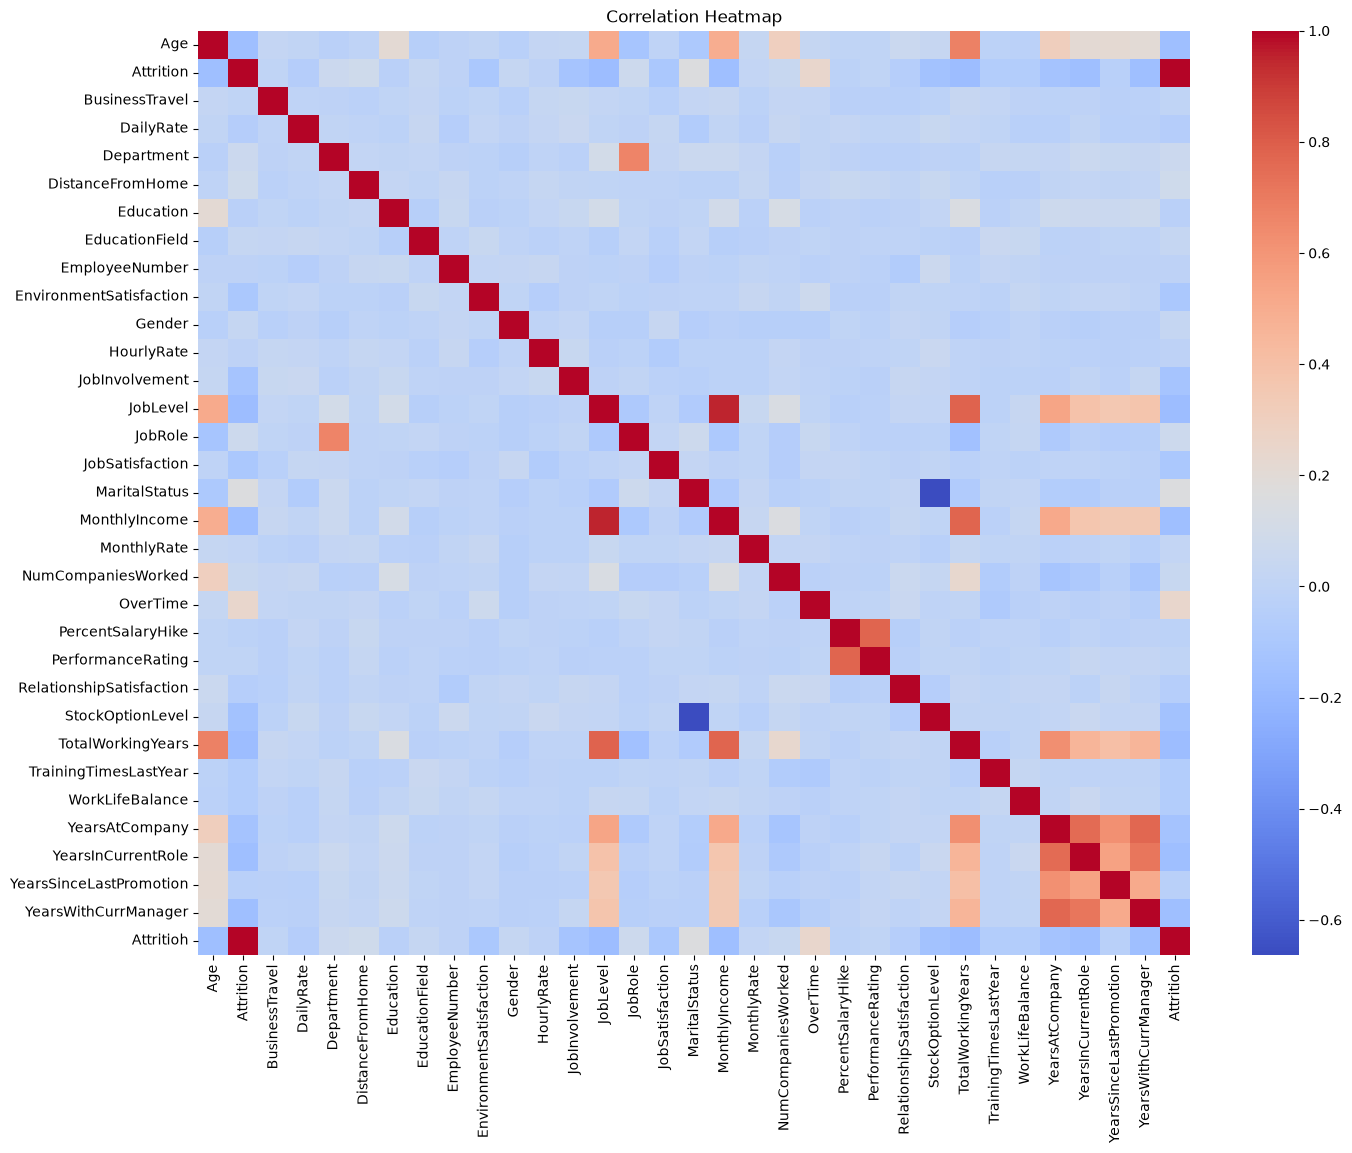

In [60]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.savefig(
    "charts/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_380\509671600.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


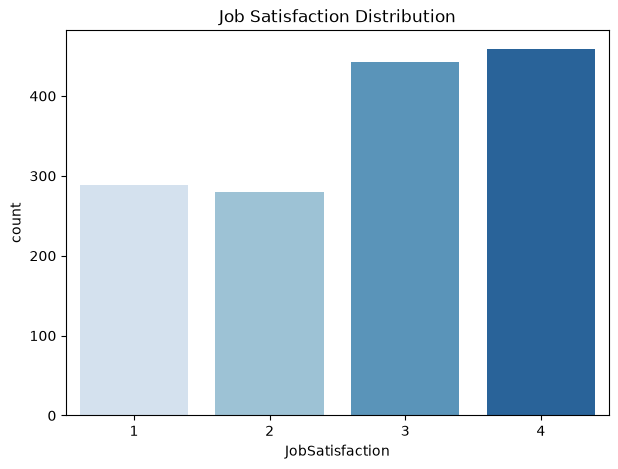

In [59]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="JobSatisfaction",
    data=df,
    palette="Blues"
)

plt.title("Job Satisfaction Distribution")

plt.savefig(
    "charts/job_satisfaction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Day 3 Observations

## Key Insights

- Dataset is imbalanced (Attrition ≈16%).
- Research & Development contains the largest workforce.
- Employees working overtime show higher attrition.
- Monthly income distribution is right-skewed.
- Most employees are aged between 30–40 years.
- Numerical variables show varying degrees of correlation.
- Job satisfaction varies across employees and may influence attrition.

Dataset is now fully explored and ready for Machine Learning.